# List 2

## Dataset

In [1]:
from torchvision.datasets import Flowers102
from torch.utils.data import DataLoader, ConcatDataset

import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

flowers_train = Flowers102(root='./data', download=True, transform=transform, split='train')
flowers_val = Flowers102(root='./data', download=True, transform=transform, split='val')
flowers_test = Flowers102(root='./data', download=True, transform=transform, split='test')

flowers_dataset = ConcatDataset([flowers_train, flowers_val, flowers_test])
dataloader = DataLoader(flowers_dataset, batch_size=32, shuffle=True)

sample_img, sample_label = flowers_dataset[0]
print(f"Total dataset size: {len(flowers_dataset)}")
print(f"Number of classes: {len(flowers_train.classes)}")
print(f"Sample image shape: {sample_img.shape}")


100%|██████████| 345M/345M [00:07<00:00, 44.7MB/s] 
100%|██████████| 502/502 [00:00<?, ?B/s] 
100%|██████████| 15.0k/15.0k [00:00<00:00, 15.0MB/s]


Total dataset size: 8189
Number of classes: 102
Sample image shape: torch.Size([3, 224, 224])


# Task 0: Do we need Transfer Learning?

## 1. 
Train a small CNN to classify the images. What results have you got? How much time did it
take? Log your results after each epoch on both the training and validation sets to monitor
progress. Provide visualizations that support your answers. You can use wandb or any other
tool.

In [2]:
import torch
from torch.utils.data import random_split
import time

import torch.nn as nn
import torch.optim as optim
import torch.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# split ds
trainval_size = int(0.8 * len(flowers_dataset))
test_size = len(flowers_dataset) - trainval_size
train_dataset, test_dataset = random_split(flowers_dataset, [trainval_size, test_size])

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])


test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [3]:
class ExampleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(ExampleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Fully connected layers
        self.c = 56*56*16
        self.fc1 = nn.Linear(self.c, 1024) # Flatten (512 * 7 * 7) features
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, self.c) # Flatten the tensor
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # logits for all classes
        return x


In [4]:
model = ExampleCNN(num_classes=102).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses, val_losses = [], []
train_accs, val_accs = [], []
start_time = time.time()

for epoch in tqdm(range(num_epochs), desc="Training"):
    # train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # val
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    tqdm.write(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
               f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTraining time: {total_time:.2f} seconds")


Training:   0%|          | 0/20 [00:00<?, ?it/s]

Train Loss: 4.2948, Train Acc: 0.0616 | Val Loss: 3.7933, Val Acc: 0.1022
Train Loss: 3.5455, Train Acc: 0.1550 | Val Loss: 3.2341, Val Acc: 0.2204
Train Loss: 2.9953, Train Acc: 0.2544 | Val Loss: 2.8651, Val Acc: 0.2937
Train Loss: 2.4056, Train Acc: 0.3721 | Val Loss: 2.5970, Val Acc: 0.3394
Train Loss: 1.7676, Train Acc: 0.5202 | Val Loss: 2.6549, Val Acc: 0.3402
Train Loss: 1.2139, Train Acc: 0.6618 | Val Loss: 2.5212, Val Acc: 0.3638
Train Loss: 0.7862, Train Acc: 0.7800 | Val Loss: 2.6983, Val Acc: 0.3616
Train Loss: 0.5030, Train Acc: 0.8532 | Val Loss: 2.6759, Val Acc: 0.3806
Train Loss: 0.3775, Train Acc: 0.8887 | Val Loss: 2.9720, Val Acc: 0.3692
Train Loss: 0.2650, Train Acc: 0.9208 | Val Loss: 2.9857, Val Acc: 0.3799
Train Loss: 0.2127, Train Acc: 0.9393 | Val Loss: 3.1968, Val Acc: 0.3524
Train Loss: 0.2066, Train Acc: 0.9452 | Val Loss: 3.1248, Val Acc: 0.3646
Train Loss: 0.1579, Train Acc: 0.9532 | Val Loss: 3.2501, Val Acc: 0.3799


KeyboardInterrupt: 

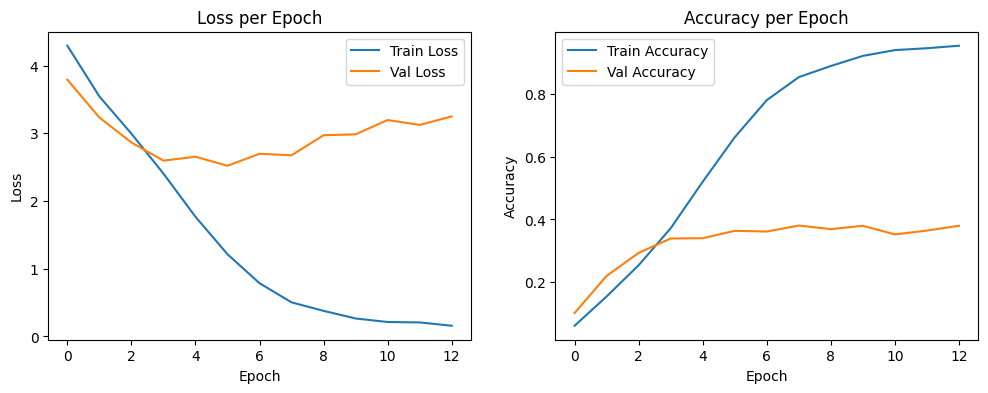

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss per Epoch')

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy per Epoch')

plt.show()


## 2. 
What if we had only 10 percent of the labeled data for training (∼ 650 examples in total)?

### train

In [6]:
flowers_dataset_10pc = torch.utils.data.Subset(flowers_dataset, list(range(int(0.1 * len(flowers_dataset)))))

# split ds
trainval_size = int(0.8 * len(flowers_dataset_10pc))
test_size = len(flowers_dataset_10pc) - trainval_size
train_dataset, test_dataset = random_split(flowers_dataset_10pc, [trainval_size, test_size])

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])


test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



class ExampleCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(ExampleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Fully connected layers
        self.c = 56*56*16
        self.fc1 = nn.Linear(self.c, 1024) # Flatten (512 * 7 * 7) features
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(-1, self.c) # Flatten the tensor
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x) # logits for all classes
        return x




In [9]:
model = ExampleCNN(num_classes=102).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 40
train_losses, val_losses = [], []
train_accs, val_accs = [], []
start_time = time.time()

for epoch in tqdm(range(num_epochs), desc="Training"):
    # train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # val
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    tqdm.write(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
               f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

total_time = time.time() - start_time
print(f"\nTraining time: {total_time:.2f} seconds")


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Train Loss: 5.2513, Train Acc: 0.0191 | Val Loss: 4.4913, Val Acc: 0.0153
Train Loss: 4.2934, Train Acc: 0.0287 | Val Loss: 4.3456, Val Acc: 0.0305
Train Loss: 3.9609, Train Acc: 0.0669 | Val Loss: 4.1933, Val Acc: 0.0534
Train Loss: 3.5773, Train Acc: 0.1224 | Val Loss: 4.0492, Val Acc: 0.0534
Train Loss: 3.1990, Train Acc: 0.2237 | Val Loss: 3.9141, Val Acc: 0.1145
Train Loss: 2.7376, Train Acc: 0.3289 | Val Loss: 3.8626, Val Acc: 0.1450
Train Loss: 2.2733, Train Acc: 0.4359 | Val Loss: 3.9227, Val Acc: 0.1298
Train Loss: 1.7631, Train Acc: 0.5449 | Val Loss: 4.0933, Val Acc: 0.1069
Train Loss: 1.4075, Train Acc: 0.6520 | Val Loss: 3.7259, Val Acc: 0.1679
Train Loss: 0.9025, Train Acc: 0.7916 | Val Loss: 4.0855, Val Acc: 0.1374
Train Loss: 0.6194, Train Acc: 0.8604 | Val Loss: 3.9670, Val Acc: 0.1603
Train Loss: 0.4020, Train Acc: 0.9082 | Val Loss: 4.0483, Val Acc: 0.1527
Train Loss: 0.2688, Train Acc: 0.9369 | Val Loss: 4.1848, Val Acc: 0.1679
Train Loss: 0.1964, Train Acc: 0.9656 

### plots

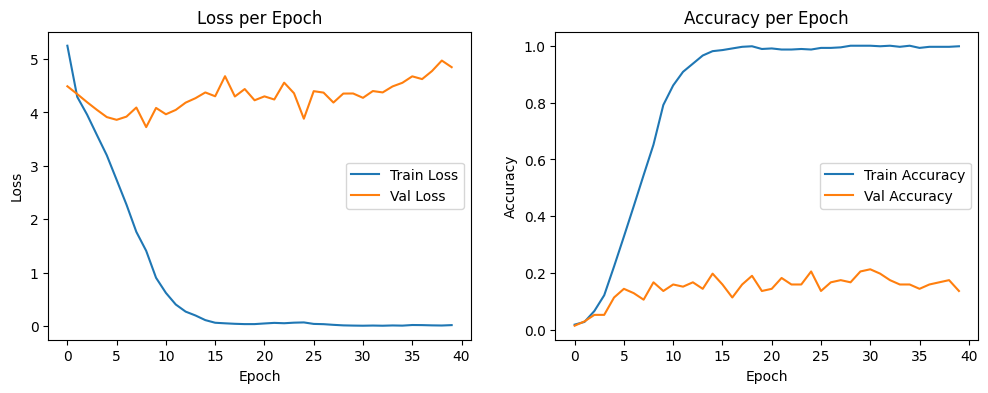

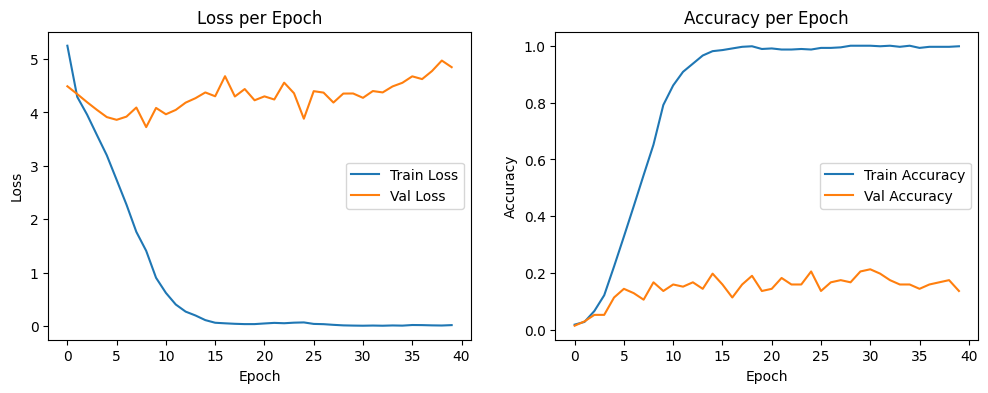

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss per Epoch')

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy per Epoch')

plt.show()



fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].set_title('Loss per Epoch')

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_title('Accuracy per Epoch')

plt.show()


## 3. 
Try to train a VGG-13 model on the considered data. How much time does it take? What
accuracy can you get? Monitor the results as previously. You can stop if the training time
exceeds 20 minutes.

In [11]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [12]:
trainval_size = int(0.8 * len(flowers_dataset))
test_size = len(flowers_dataset) - trainval_size
trainval_dataset, test_dataset = random_split(flowers_dataset, [trainval_size, test_size])

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size])

batch_size = 16
train_loader_vgg = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_vgg = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader_vgg = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
vgg13_model = models.vgg13(weights=None)
vgg13_model.classifier[-1] = nn.Linear(vgg13_model.classifier[-1].in_features, 102)
vgg13_model = vgg13_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg13_model.parameters(), lr=1e-4)

num_epochs = 50
max_training_time_seconds = 20 * 60

vgg_train_losses, vgg_val_losses = [], []
vgg_train_accs, vgg_val_accs = [], []

start_time = time.time()
epochs_completed = 0

for epoch in tqdm(range(num_epochs), desc="Training", leave=True):
    elapsed = time.time() - start_time
    if elapsed > max_training_time_seconds:
        tqdm.write(f"Stopping early: exceeded 20 minutes before epoch {epoch + 1}.")
        break

    # train
    vgg13_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader_vgg, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg13_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader_vgg)
    train_acc = train_correct / train_total
    vgg_train_losses.append(train_loss)
    vgg_train_accs.append(train_acc)

    # validation
    vgg13_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader_vgg, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = vgg13_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader_vgg)
    val_acc = val_correct / val_total
    vgg_val_losses.append(val_loss)
    vgg_val_accs.append(val_acc)

    epochs_completed += 1
    epoch_elapsed = time.time() - start_time
    tqdm.write(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
        f"Elapsed: {epoch_elapsed:.1f}s"
    )

    if epoch_elapsed > max_training_time_seconds:
        tqdm.write("Stopping early: exceeded 20 minutes after finishing the epoch.")
        break

total_time = time.time() - start_time
print(f"\nTraining finished in {total_time:.2f} seconds ({total_time/60:.2f} minutes).")
print(f"Epochs completed: {epochs_completed}")



Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/50 [Train]:   0%|          | 0/328 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 2.6735, Train Acc: 0.3683 | Val Loss: 1.1205, Val Acc: 0.6873 | Elapsed: 121.0s


Epoch 2/50 [Train]:   0%|          | 0/328 [00:00<?, ?it/s]

...

Epoch 9/50 [Val]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 9/50 | Train Loss: 0.0522, Train Acc: 0.9865 | Val Loss: 0.4857, Val Acc: 0.8726 | Elapsed: 1081.9s


Epoch 10/50 [Train]:   0%|          | 0/328 [00:00<?, ?it/s]

Epoch 10/50 [Val]:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 10/50 | Train Loss: 0.0657, Train Acc: 0.9811 | Val Loss: 0.5265, Val Acc: 0.8772 | Elapsed: 1201.7s
Stopping early: exceeded 20 minutes after finishing the epoch.

Training finished in 1201.70 seconds (20.03 minutes).
Epochs completed: 10


In [16]:
# test accuracy
vgg13_model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for images, labels in test_loader_vgg:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg13_model(images)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

test_acc = test_correct / test_total if test_total > 0 else 0.0
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8767


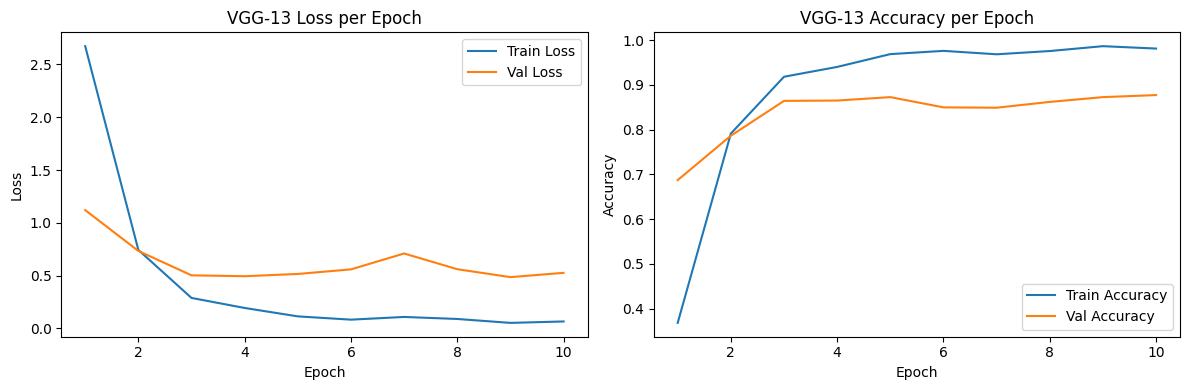

In [17]:
# plots
epochs_range = range(1, len(vgg_train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, vgg_train_losses, label='Train Loss')
axes[0].plot(epochs_range, vgg_val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('VGG-13 Loss per Epoch')
axes[0].legend()

axes[1].plot(epochs_range, vgg_train_accs, label='Train Accuracy')
axes[1].plot(epochs_range, vgg_val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('VGG-13 Accuracy per Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 
Look into the paper proposing the VGG-13 model (https://arxiv.org/pdf/1409.1556). What
dataset has it been pretrained on? What’s the size of this dataset? How much time did it take?

- ILSVRC-2012 dataset
- 1000 classes
  - training: 1.3M images
  - validation: 50K images
  - testing: 100K images with held-out labels
- "On a system equipped with four NVIDIA Titan Black GPUs, training a single net took 2–3 weeks depending on the architecture."

# Task 1: Transfer Learning [4 points]


1. Use transfer learning to classify the flowers:
- Use a pre-trained VGG-13 model: https://docs.pytorch.org/vision/main/models/vgg.html.
- Freeze the convolutional layers, re-initialize the parameters from the last layer, and train
the parameters from the last layer only. Monitor the training.
- Evaluate the final model.

In [8]:
!pip install wandb -q

In [2]:
import copy
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [41]:
LAYERS = 6

run = wandb.init(
    entity="fejowo5522-",
    project="ADM2",
    name="VGG13 - full training",
    config={
        "frozen layers": LAYERS
    },
)

In [42]:
trainval_size = int(0.8 * len(flowers_dataset))
test_size = len(flowers_dataset) - trainval_size
trainval_dataset, test_dataset = random_split(flowers_dataset, [trainval_size, test_size])

train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size])

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [43]:
weights = models.VGG13_Weights.DEFAULT
vgg13 = models.vgg13(weights=weights)

# freeze all parameters
for param in vgg13.parameters():
    param.requires_grad = False

# setup last layer
in_features = vgg13.classifier[-1].in_features
vgg13.classifier[-1] = nn.Linear(in_features, 102)
nn.init.xavier_uniform_(vgg13.classifier[-1].weight)
nn.init.zeros_(vgg13.classifier[-1].bias)

# train last layers
n_layers = len(vgg13.classifier)
for i in range(-LAYERS, 0):
    for param in vgg13.classifier[i].parameters():
        param.requires_grad = True

for param in vgg13.classifier[-1].parameters():
    param.requires_grad = True


vgg13 = vgg13.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg13.classifier[-1].parameters(), lr=1e-3)

num_epochs = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0
best_state = copy.deepcopy(vgg13.state_dict())
start_time = time.time()

for epoch in tqdm(range(num_epochs), desc='Transfer Learning Training'):
    # train
    vgg13.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg13(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    epoch_train_loss = train_loss / len(train_loader)
    epoch_train_acc = train_correct / train_total if train_total > 0 else 0.0

    # val
    vgg13.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg13(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = val_correct / val_total

    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_state = copy.deepcopy(vgg13.state_dict())

    tqdm.write(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}"
    )
    run.log({
        "epoch": epoch + 1,
        "time": time.time() - start_time,
        "train_loss": epoch_train_loss,
        "train_acc": epoch_train_acc,
        "val_loss": epoch_val_loss,
        "val_acc": epoch_val_acc
    })

training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Best validation accuracy: {best_val_acc:.4f}")


Transfer Learning Training:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 2.2652, Train Acc: 0.4595 | Val Loss: 1.0080, Val Acc: 0.7368
Epoch 02/15 | Train Loss: 1.0407, Train Acc: 0.7122 | Val Loss: 0.8087, Val Acc: 0.7796
Epoch 03/15 | Train Loss: 0.8128, Train Acc: 0.7637 | Val Loss: 0.7255, Val Acc: 0.8002
Epoch 04/15 | Train Loss: 0.6725, Train Acc: 0.8013 | Val Loss: 0.7235, Val Acc: 0.8032
Epoch 05/15 | Train Loss: 0.5857, Train Acc: 0.8296 | Val Loss: 0.7367, Val Acc: 0.7834
Epoch 06/15 | Train Loss: 0.5181, Train Acc: 0.8443 | Val Loss: 0.6537, Val Acc: 0.8230
Epoch 07/15 | Train Loss: 0.4934, Train Acc: 0.8527 | Val Loss: 0.6491, Val Acc: 0.8207
Epoch 08/15 | Train Loss: 0.4645, Train Acc: 0.8565 | Val Loss: 0.6163, Val Acc: 0.8124
Epoch 09/15 | Train Loss: 0.4103, Train Acc: 0.8716 | Val Loss: 0.6072, Val Acc: 0.8375
Epoch 10/15 | Train Loss: 0.3985, Train Acc: 0.8721 | Val Loss: 0.6533, Val Acc: 0.8230
Epoch 11/15 | Train Loss: 0.3663, Train Acc: 0.8830 | Val Loss: 0.6357, Val Acc: 0.8322
Epoch 12/15 | Train Loss: 0.3603

In [44]:
vgg13.load_state_dict(best_state)

vgg13.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = vgg13(images)
        _, preds = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (preds == labels).sum().item()

test_acc = test_correct / test_total if test_total > 0 else 0.0
print(f"Test accuracy: {test_acc:.4f}")
run.log({"test_acc": test_acc})

Test accuracy: 0.8187


In [45]:
torch.save(vgg13, f"data/vgg13_frozen_{LAYERS}_layers.pth")

run.finish()

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
time,▁▁▂▂▃▃▄▄▅▅▆▆▇██
train_acc,▁▅▆▇▇▇▇▇███████
train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▄▅▆▄▇▇▆█▇██▇▇▇
val_loss,█▅▃▃▃▂▂▁▁▂▁▁▁▂▂
epoch,15
test_acc,0.81868
time,572.72947
train_acc,0.89294


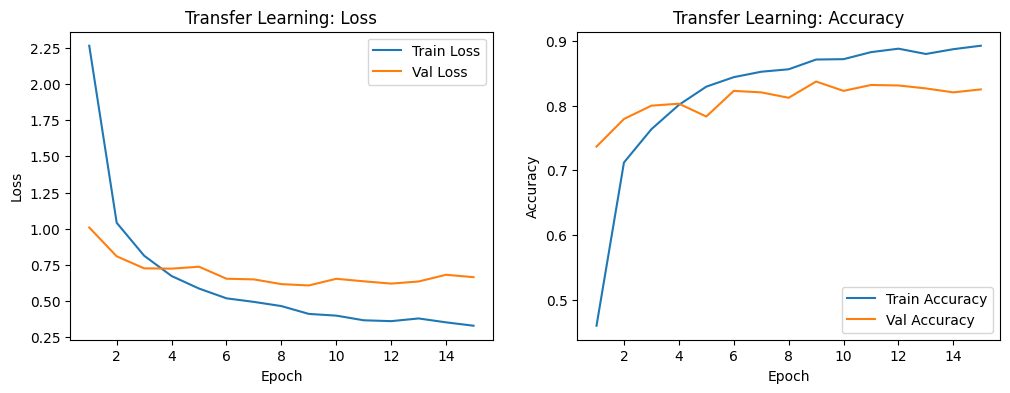

In [46]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_losses, label='Train Loss')
axes[0].plot(epochs, val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Transfer Learning: Loss')
axes[0].legend()

axes[1].plot(epochs, train_accs, label='Train Accuracy')
axes[1].plot(epochs, val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Transfer Learning: Accuracy')
axes[1].legend()

plt.show()


## 2. Study of the properties of transfer learning:
- Repeat the above experiment by freezing the first 1, 2, . . . , 6 layers.
- Log the time consumption and accuracy on a validation set after each epoch. Train until
convergence. Remember to save your models after training.
- Plot the accuracy obtained and the time consumed for each experiment.
- Plot the time consumed and the number of epochs needed to obtain 95% accuracy in each
experiment (you can use other reasonable threshold).

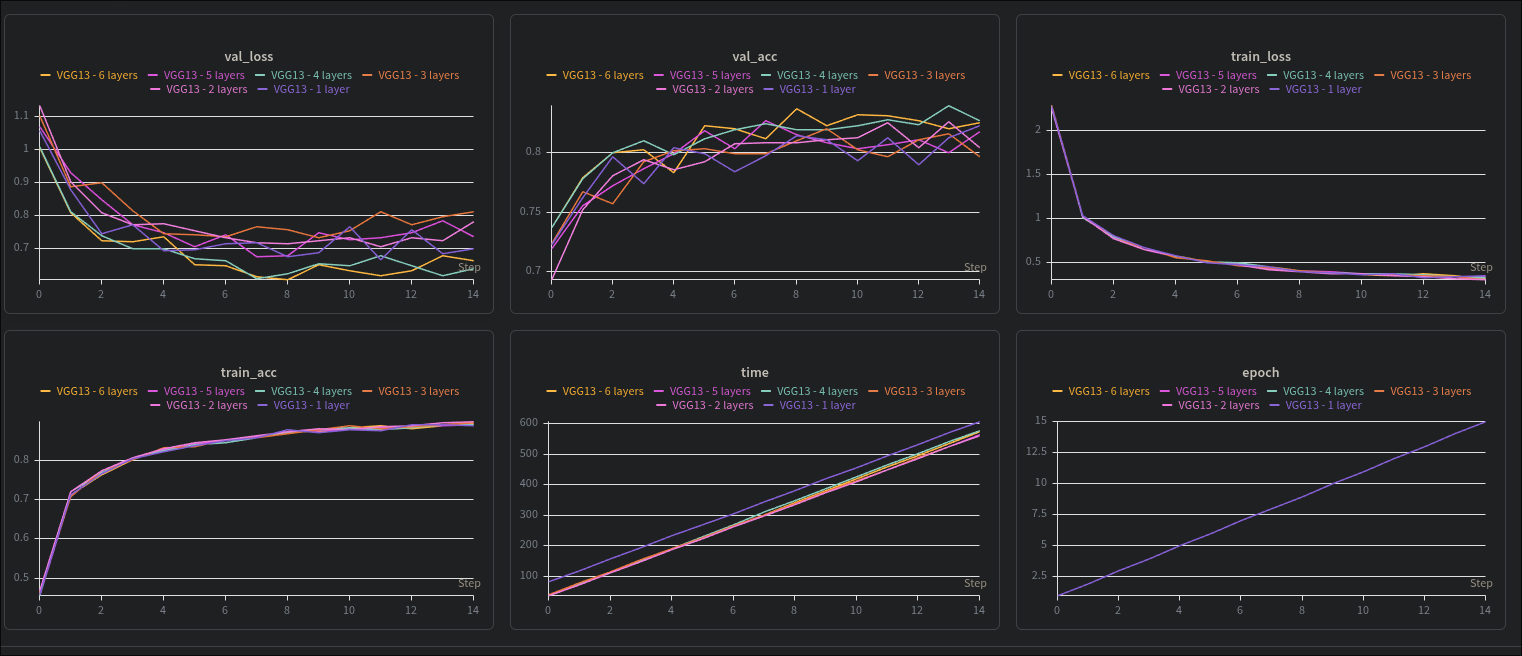

# Task 2: Contrasive Learning [4 points]

In this task, you will run a toy example of semi-supervised learning on the MNIST dataset. The first
step is to use contrastive learning to train a model that provides good representations. Then, you
will have to train a classifier using only a small portion of the labels.
- Sample 5 labeled examples per digit. If it doesn’t work, try to figure out a minimal portion of
labeled data needed to train a classifier on the representations you will obtain. If you update
the size of the labeled dataset, keep track of the changes you made; note down the results you
got that you were not satisfied with.
- Think of augmentations suitable for the task (consider if rotations and color distortions make
sense in the case of MNIST).
- Train a small ConvNet with a contrastive loss. You can take inspiration from this tutorial (but
please note it does not solve the entire task, as it does not use data augmentations). You can
use an architecture similar to SimCLR (but with simpler encoder and projection modules).
- Build a classifier. You can cluster the obtained representations (or, if needed, their projections)
and try to assign the labels to each group, or run a simple classifier like kNN or a MLP classifier.

In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
class ContrastiveMNISTPairs(Dataset):
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]
        view1 = self.transform(image)
        view2 = self.transform(image)
        return view1, view2

def make_n_per_class_subset_indices(targets, n_per_class=5):
    targets = np.asarray(targets)
    indices = []
    for digit in range(10):
        cls_idx = np.where(targets == digit)[0]
        pick = np.random.choice(cls_idx, size=n_per_class, replace=False)
        indices.extend(pick.tolist())
    np.random.shuffle(indices)
    return indices


train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=15, translate=(0.10, 0.10), scale=(0.90, 1.10), shear=10),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

mnist_train_raw = datasets.MNIST(root='./data', train=True, download=True)
mnist_train_eval = datasets.MNIST(root='./data', train=True, download=False, transform=eval_transform)
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=eval_transform)

contrastive_ds = ContrastiveMNISTPairs(mnist_train_raw, train_transform)
contrastive_loader = DataLoader(contrastive_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

test_loader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples: {len(contrastive_ds)}')
print(f'Test samples: {len(mnist_test)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.11MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

Train samples: 60000
Test samples: 10000


In [3]:
class SmallEncoder(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 7x7
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.fc = nn.Linear(128, feature_dim)

    def forward(self, x):
        x = self.features(x).flatten(1)
        x = self.fc(x)
        x = F.normalize(x, dim=1)
        return x


class ProjectionHead(nn.Module):
    def __init__(self, in_dim=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim),
            nn.ReLU(inplace=True),
            nn.Linear(in_dim, proj_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)


def nt_xent_loss(z1, z2, temperature=0.2):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e9)

    targets = torch.arange(batch_size, device=z.device)
    targets = torch.cat([targets + batch_size, targets], dim=0)

    return F.cross_entropy(sim, targets)


encoder = SmallEncoder(feature_dim=128).to(device)
projector = ProjectionHead(in_dim=128, proj_dim=64).to(device)
params = list(encoder.parameters()) + list(projector.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3, weight_decay=1e-4)

contrastive_epochs = 8
temperature = 0.2
contrastive_losses = []

start = time.time()
for epoch in range(contrastive_epochs):
    encoder.train()
    projector.train()
    running_loss = 0.0

    for x1, x2 in contrastive_loader:
        x1, x2 = x1.to(device), x2.to(device)

        h1 = encoder(x1)
        h2 = encoder(x2)
        z1 = projector(h1)
        z2 = projector(h2)

        loss = nt_xent_loss(z1, z2, temperature=temperature)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(contrastive_loader)
    contrastive_losses.append(epoch_loss)
    print(f'Epoch {epoch + 1:02d}/{contrastive_epochs} | Contrastive loss: {epoch_loss:.4f}')

print(f'Contrastive pretraining time: {time.time() - start:.1f}s')

Epoch 01/8 | Contrastive loss: 3.2379
Epoch 02/8 | Contrastive loss: 2.5550
Epoch 03/8 | Contrastive loss: 2.4185
Epoch 04/8 | Contrastive loss: 2.3458
Epoch 05/8 | Contrastive loss: 2.2933
Epoch 06/8 | Contrastive loss: 2.2659
Epoch 07/8 | Contrastive loss: 2.2382
Epoch 08/8 | Contrastive loss: 2.2152
Contrastive pretraining time: 588.8s


In [4]:
def extract_features(encoder_model, loader):
    with torch.no_grad():
        encoder_model.eval()
        feats, labels = [], []
        for x, y in loader:
            x = x.to(device)
            h = encoder_model(x)
            feats.append(h)
            labels.append(y)
        return torch.cat(feats, dim=0), torch.cat(labels, dim=0)


class LinearProbe(nn.Module):
    def __init__(self, in_dim=128, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def fine_tune(n_per_class=5, epochs=80, lr=5e-2, wd=1e-4):
    train_targets = mnist_train_raw.targets.numpy()
    labeled_indices = make_n_per_class_subset_indices(train_targets, n_per_class=n_per_class)

    labeled_ds = Subset(mnist_train_eval, labeled_indices)
    labeled_loader = DataLoader(labeled_ds, batch_size=min(256, len(labeled_ds)), shuffle=True)

    X_test, y_test = extract_features(encoder, test_loader)

    probe = LinearProbe(in_dim=128, num_classes=10).to(device)
    opt = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'test_acc': []}
    train_acc = [], test_acc = []

    for _ in range(epochs):
        probe.train()
        for x_lab, y_lab in labeled_loader:
            with torch.no_grad():
                h = encoder(x_lab.to(device))
            y_lab = y_lab.to(device)

            logits = probe(h)
            loss = criterion(logits, y_lab)

            opt.zero_grad()
            loss.backward()
            opt.step()

        probe.eval()
        with torch.no_grad():
            train_correct = 0
            train_total = 0
            for x_lab, y_lab in labeled_loader:
                h = encoder(x_lab.to(device))
                pred = probe(h).argmax(dim=1).cpu()
                train_correct += (pred == y_lab).sum().item()
                train_total += y_lab.size(0)
            train_acc = train_correct / train_total

            pred_test = probe(X_test.to(device)).argmax(dim=1).cpu()
            test_acc = accuracy_score(y_test.numpy(), pred_test.numpy())

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

    # # Optional kNN on the same features as reference
    # X_lab, y_lab = extract_features(encoder, DataLoader(labeled_ds, batch_size=256, shuffle=False))
    # knn = KNeighborsClassifier(n_neighbors=min(3, len(X_lab)))
    # knn.fit(X_lab.numpy(), y_lab.numpy())
    # knn_test_acc = knn.score(X_test.numpy(), y_test.numpy())

    return {
        'n_per_class': n_per_class,
        'n_labeled_total': len(labeled_indices),
        'linear_best_test_acc': float(max(history['test_acc'])),
        'linear_last_test_acc': float(history['test_acc'][-1]),
        # 'knn_test_acc': float(knn_test_acc),
        'history': history,
    }

In [5]:
target_test_acc = 0.90
candidate_n_per_class = [5, 10, 20, 50]

experiment_log = []
unsatisfactory_runs = []
selected_result = None

for n in candidate_n_per_class:
    print(f'\nRunning few-label experiment with n_per_class={n} ({10*n} labels total)')
    result = fine_tune(n_per_class=n, epochs=80)
    experiment_log.append(result)

    best_acc = result['linear_best_test_acc']
    print(
        f"Best linear-probe test acc: {best_acc:.4f} | "
        f"Final linear-probe test acc: {result['linear_last_test_acc']:.4f} | "
        f"kNN test acc: {result['knn_test_acc']:.4f}"
    )

    if best_acc >= target_test_acc and selected_result is None:
        selected_result = result
        print(f'--> Reached threshold {target_test_acc:.2f} with n_per_class={n}.')
        break
    else:
        unsatisfactory_runs.append({
            'n_per_class': n,
            'labels_total': 10 * n,
            'best_linear_test_acc': best_acc,
            'reason': f'Below threshold {target_test_acc:.2f}'
        })

if selected_result is None:
    selected_result = experiment_log[-1]
    print('\nNo run reached the target threshold; using the best available run for reporting.')

print('\nSelected run:')
print(selected_result)


Running few-label experiment with n_per_class=5 (50 labels total)


ValueError: not enough values to unpack (expected 2, got 0)

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(contrastive_losses) + 1), contrastive_losses, marker='o')
plt.title('Contrastive pretraining loss')
plt.xlabel('Epoch')
plt.ylabel('NT-Xent loss')
plt.grid(True, alpha=0.3)
plt.show()

labels_totals = [r['n_labeled_total'] for r in experiment_log]
best_linear = [r['linear_best_test_acc'] for r in experiment_log]
knn_accs = [r['knn_test_acc'] for r in experiment_log]

plt.figure(figsize=(7, 4))
plt.plot(labels_totals, best_linear, marker='o', label='Linear probe (best test acc)')
plt.plot(labels_totals, knn_accs, marker='s', label='kNN (test acc)')
plt.title('Accuracy vs number of labeled samples')
plt.xlabel('Number of labeled samples')
plt.ylabel('Test accuracy')
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('===== Unsatisfactory runs (required log) =====')
if len(unsatisfactory_runs) == 0:
    print('None. The first setup already met the target threshold.')
else:
    for run in unsatisfactory_runs:
        print(run)

print('\n===== Final selected configuration =====')
print(f"n_per_class: {selected_result['n_per_class']}")
print(f"Total labeled examples: {selected_result['n_labeled_total']}")
print(f"Best linear-probe test accuracy: {selected_result['linear_best_test_acc']:.4f}")
print(f"kNN test accuracy: {selected_result['knn_test_acc']:.4f}")

### Short conclusions (fill after running)

- **Augmentations used:** small affine transforms + slight blur; no color jitter.
- **Why:** they preserve MNIST digit identity while adding realistic handwritten variation.
- **5 labels/digit outcome:** _(fill from output)_
- **Unsatisfactory runs tried:** _(copy from printed `unsatisfactory_runs`)_
- **Minimal label portion that worked:** _(e.g., 10 / 20 / 50 per digit)_
- **Final classifier used:** linear probe on frozen contrastive features (with kNN reference).